In [17]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
ias15_2 = pd.read_csv(
    "embryo_ias15_Jul10/famtree_2",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)
ias15_2

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,86.01725,4,31,4,29,8.304772e-07,5.168290e-07,3.913242e-07,0.000034,0.000029,0.000026,1.140499,0.312626
1,86.01725,4,32,4,29,7.767599e-08,5.168290e-07,3.913242e-07,0.000015,0.000029,0.000026,1.140499,0.312626
2,983.20000,2,34,15,8,9.689160e-07,5.352333e-07,4.336826e-07,0.000036,0.000029,0.000027,1.187692,0.949853


In [19]:
coll_1 = ias15_2[ias15_2['parent1_id'] == 4]
t1 = coll_1['t'].iloc[0]

In [20]:
ias15_2_archive = rebound.Simulationarchive("embryo_ias15_Jul10/ias15_2_det.bin")

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:103: RuntimeWarning: The binary file seems to be corrupted. An attempt has been made to read the uncorrupted parts of it.
  warnings.warn(message, RuntimeWarning)


In [21]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [22]:
len(ias15_2_archive)

2628

In [23]:
ias15_2_times = []
ias15_2_n_bodies = []
ias15_2_masses = []
ias15_2_mass_errors = []
ias15_2_angular_momentums = []
ias15_2_L_rel_errors = []
ias15_2_Es = []
ias15_2_E_rel_errors = []
snapshot_idxs = []

for i in range(len(ias15_2_archive)):
    snap = ias15_2_archive[i]
    snapshot_idxs.append(i)
    ias15_2_times.append(snap.t)
    ias15_2_n_bodies.append(snap.N)

    Lx, Ly, Lz = snap.angular_momentum()
    ias15_2_angular_momentums.append(get_abs(Lx, Ly, Lz))
    ias15_2_Es.append(snap.energy())

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    ias15_2_masses.append(m)

for i in range(len(ias15_2_masses)):
    diff = np.abs((ias15_2_masses[i] - ias15_2_masses[0]))
    rel_diff = diff/np.abs(ias15_2_masses[0])
    ias15_2_mass_errors.append(rel_diff)

for i in range(len(ias15_2_angular_momentums)):
    diff = np.abs(ias15_2_angular_momentums[i] - ias15_2_angular_momentums[0])
    ias15_2_L_rel_errors.append(diff/np.abs(ias15_2_angular_momentums[0]))

for i in range(len(ias15_2_Es)):
    diff = np.abs(ias15_2_Es[i] - ias15_2_Es[0])
    ias15_2_E_rel_errors.append(diff/np.abs(ias15_2_Es[0]))


ias15_2_dict = {
    't': ias15_2_times,
    'N_Bodies': ias15_2_n_bodies,
    'total_masses': ias15_2_masses,
    'm_errors': ias15_2_mass_errors,
    'angular_momentums': ias15_2_angular_momentums,
    'L_rel_errors': ias15_2_L_rel_errors,
    'E': ias15_2_Es,
    'E_rel_errors': ias15_2_E_rel_errors,
    'snapshot_idx': snapshot_idxs
}

ias15_2_archive_df = pd.DataFrame(ias15_2_dict)

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [24]:
close_up = ias15_2_archive_df[(ias15_2_archive_df['t'] < t1 + 10) & (ias15_2_archive_df['t'] > t1 - 10)]
close_up

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors,snapshot_idx
366,76.017362,31,1.000008,0.0,0.000026,0.000000e+00,-0.000592,6.042633e-15,366
367,76.033817,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,5.676413e-15,367
368,76.050116,31,1.000008,0.0,0.000026,2.564763e-16,-0.000592,2.929762e-15,368
369,76.066561,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,5.676413e-15,369
370,76.082995,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,4.577753e-15,370
...,...,...,...,...,...,...,...,...,...
1578,95.940466,31,1.000008,0.0,0.000026,2.416717e-03,-0.000546,7.804159e-02,1578
1579,95.956818,31,1.000008,0.0,0.000026,2.416717e-03,-0.000546,7.804159e-02,1579
1580,95.973987,31,1.000008,0.0,0.000026,2.416717e-03,-0.000546,7.804159e-02,1580
1581,95.990378,31,1.000008,0.0,0.000026,2.416717e-03,-0.000546,7.804159e-02,1581


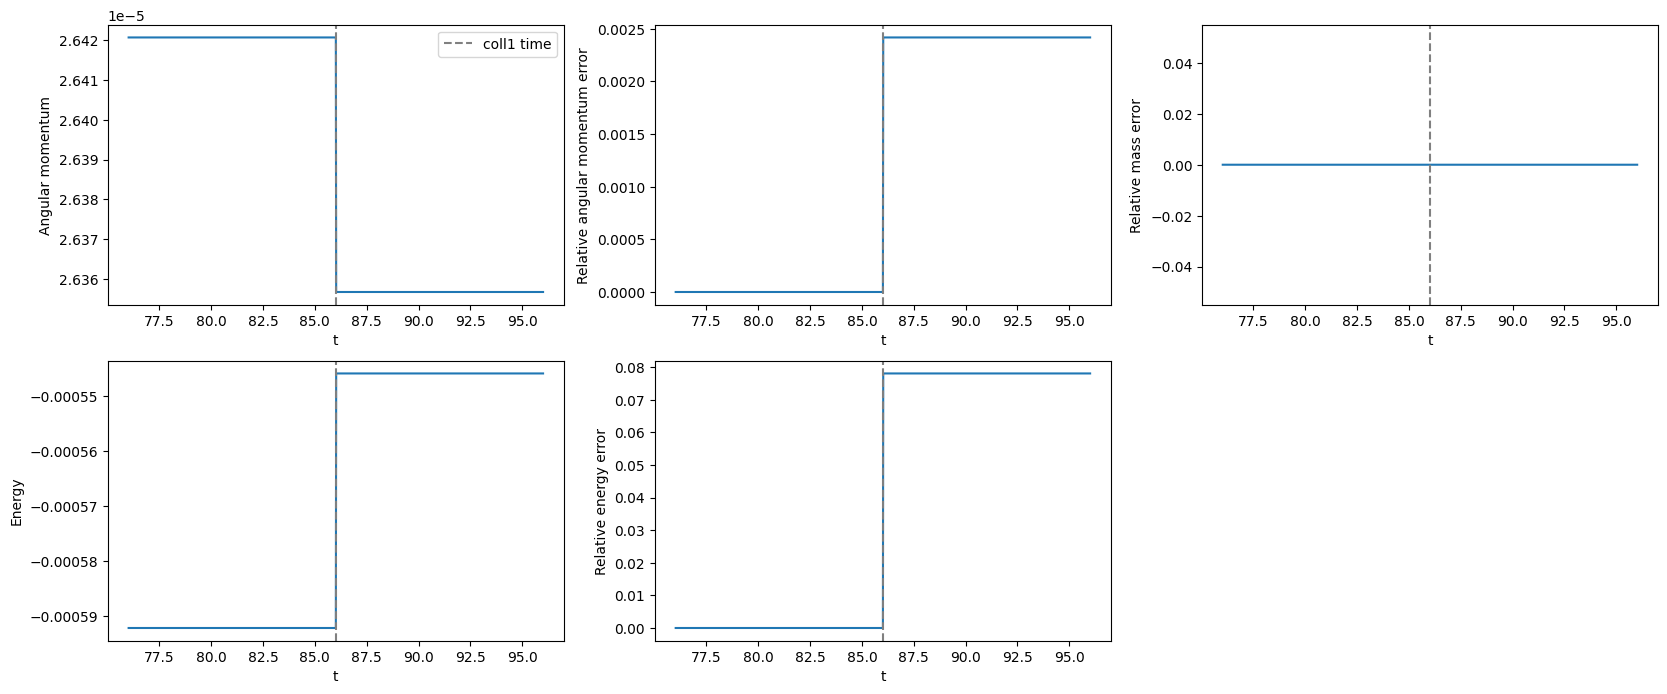

In [25]:
plt.figure(figsize=(20,8))
plt.subplot(2,3,1)
plt.plot(close_up['t'], close_up['angular_momentums'])
plt.xlabel('t')
plt.ylabel("Angular momentum")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')
plt.legend()

plt.subplot(2,3,2)
plt.plot(close_up['t'], close_up['L_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative angular momentum error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,3)
plt.plot(close_up['t'], close_up['m_errors'])
plt.xlabel('t')
plt.ylabel("Relative mass error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,4)
plt.plot(close_up['t'], close_up['E'])
plt.xlabel('t')
plt.ylabel("Energy")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,5)
plt.plot(close_up['t'], close_up['E_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative energy error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

In [26]:
idx_before = 8
idx_after = 9

snap_before = ias15_2_archive[idx_before]
snap_after = ias15_2_archive[idx_after]

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [47]:
# Based on the famtree (collision output) file. Using this mass, we can find the particles right before the collision.

m_parent1 = coll_1['parent1_mass'].iloc[0]
m_parent2 = coll_1['parent2_mass'].iloc[0]
r_parent1 = coll_1['parent1_radius'].iloc[0]
r_parent2 = coll_1['parent2_radius'].iloc[0]

m_frag1 = coll_1['new_mass'].iloc[0]
m_frag2 = coll_1['new_mass'].iloc[1]

print("parent1 mass in famtree = ", m_parent1)
print("parent2 mass in famtree = ", m_parent2)

parent1 mass in famtree =  5.16829e-07
parent2 mass in famtree =  3.913242e-07


In [46]:
for i in range(snap_before.N):
    particle = snap_before.particles[i]
    if np.isclose(particle.m, m_parent1, atol=1e-11):
        parent1_before = particle
        print("parent1 found in archive, mass = ", particle.m)

    if np.isclose(particle.m, m_parent2, atol=1e-11):
        parent2_before = particle
        print("parent2 found in archive, mass = ", particle.m)

parent1 found in archive, mass =  5.168289745479957e-07
parent2 found in archive, mass =  3.9132422304382745e-07


In [48]:
for i in range(snap_after.N):
    particle = snap_after.particles[i]
    if np.isclose(particle.m, m_frag1, atol=1e-11):
        frag1 = particle
        print("frag1 mass = ", particle.m)

    if np.isclose(particle.m, m_frag2, atol=1e-11):
        frag2 = particle
        print("frag2 mass = ", particle.m)

lr_mass = np.max([frag1.m, frag2.m])
small_frags = [frag2]

In [30]:
coll_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,86.01725,4,31,4,29,8.304772e-07,5.168290e-07,3.913242e-07,0.000034,0.000029,0.000026,1.140499,0.312626
1,86.01725,4,32,4,29,7.767599e-08,5.168290e-07,3.913242e-07,0.000015,0.000029,0.000026,1.140499,0.312626


In [55]:
# 1. Determine Target and Projectile based on mass (Target is >= Projectile)
if parent1_before.m >= parent2_before.m:
    target = parent1_before
    projectile = parent2_before
else:
    target = parent2_before
    projectile = parent1_before

initial_mass = target.m + projectile.m

# 2. Setup initial vectors
v_target = np.array([target.vx, target.vy, target.vz])
v_proj = np.array([projectile.vx, projectile.vy, projectile.vz])
r_target = np.array([target.x, target.y, target.z])
r_proj = np.array([projectile.x, projectile.y, projectile.z])

v_com = (target.m * v_target + projectile.m * v_proj) / initial_mass
r_com = (target.m * np.array(target.xyz) + projectile.m * np.array(projectile.xyz)) / initial_mass

# 3. Calculate internal expansion velocity 
# Note: Replicating the frame-dependent logic currently in the C code
v_lr = np.linalg.norm(v_com)

# 4. Relative vectors & Collision Plane
dv = v_target - v_proj
dr = r_target - r_proj
unit_dv = dv / np.linalg.norm(dv)

normal_coll_plane = np.cross(dv, dr)
mag_ncp = np.linalg.norm(normal_coll_plane)

# Collinear fallback (replicating C code lines 241-250)
if mag_ncp < 1e-15:
    arb_vec = np.cross(unit_dv, np.array([1.0, 0.0, 0.0]))
    if np.linalg.norm(arb_vec) < 1e-15:
        arb_vec = np.cross(unit_dv, np.array([0.0, 1.0, 0.0]))
    normal_coll_plane = arb_vec
    mag_ncp = np.linalg.norm(normal_coll_plane)

normal_coll_plane = normal_coll_plane / mag_ncp
normal_to_vrel = np.cross(dv, normal_coll_plane)
normal_to_vrel = normal_to_vrel / np.linalg.norm(normal_to_vrel)

# 5. Map fragments 
n_frag = len(small_frags) + 1
theta_sep = (2.0 * np.pi) / n_frag

# 6. Assign Initial Velocities and Track Momentum
mvsum = lr_mass * v_com 
target_v_raw = v_com 

frag_velocities_raw = []

for j, frag in enumerate(small_frags, start=1):
    frag_velocity_mag = v_lr * np.sqrt(lr_mass / frag.m)
    
    cos_t = np.cos(theta_sep * j)
    sin_t = np.sin(theta_sep * j)
    
    v_frag_raw = v_com + frag_velocity_mag * (cos_t * unit_dv + sin_t * normal_to_vrel)
    frag_velocities_raw.append({'mass': frag.m, 'v_raw': v_frag_raw})
    
    mvsum += frag.m * v_frag_raw

# 7. Momentum Offset Correction 
voff = v_com - (mvsum / initial_mass)
target_v_final = target_v_raw + voff * (lr_mass / initial_mass)
#target_v_final = target_v_raw
print(f"Largest Remnant Expected v: {target_v_final}, abs = {get_abs(target_v_final[0], target_v_final[1], target_v_final[2])}")

for j, frag_dict in enumerate(frag_velocities_raw):
    v_frag_final = frag_dict['v_raw'] + voff * (frag_dict['mass'] / initial_mass)
    print(f"Small Fragment Expected v: {v_frag_final}, abs = {get_abs(v_frag_final[0], v_frag_final[1], v_frag_final[2])}")

Largest Remnant Expected v: [-0.59872958  5.30580162  0.05911583], abs = 5.33980361262752
Small Fragment Expected v: [15.29027296 -0.97660037 -0.09566668], abs = 15.321727952419751


In [32]:
print(f"parent1 vx = {parent1_before.vx}, vy = {parent1_before.vy}, vz = {parent1_before.vz}")
print(f"parent2 vx = {parent2_before.vx}, vy = {parent2_before.vy}, vz = {parent2_before.vz}")
print(f"frag1 vx = {frag1.vx}, vy = {frag1.vy}, vz = {frag1.vz}, |v| = {get_abs(frag1.vx, frag1.vy, frag1.vz)}")
print(f"frag2 vx = {frag2.vx}, vy = {frag2.vy}, vz = {frag2.vz}, |v| = {get_abs(frag2.vx, frag2.vy, frag2.vz)}")

parent1 vx = -6.964033676080849, vy = 7.822598943269375, vz = 0.1211233609580243
parent2 vx = 10.501227659220177, vy = 0.9169551044856739, vz = -0.04901426090856765
frag1 vx = -5.596519766900577, vy = 6.87238207545979, vz = -0.6617000546311506, |v| = 8.887548360189596
frag2 vx = -25.91836302206698, vy = 3.1569574429083467, vz = 8.114202037410246, |v| = 27.341693377402503


Based on the print statements, these are target and projectile and com velocities and positions:

pi_mass = 5.168290e-07, pj_mass = 3.913242e-07

target_mass = 5.168290e-07, proj_mass = 3.913242e-07

com.x = 3.531003e-01, com.y = -6.644252e-02, com.z = -2.024119e-03

com.vx = 1.975706e+00, com.vy = 1.030943e+01, com.vz = 5.393658e-02

target.x = 3.531148e-01, target.y = -6.642956e-02, target.z = -2.037569e-03

target.vx = 1.592233e+00, target.vy = 1.016868e+01, target.vz = 3.271638e-01

proj.x = 3.530812e-01, proj.y = -6.645963e-02, proj.z = -2.006355e-03

proj.vx = 2.482166e+00, proj.vy = 1.049532e+01, proj.vz = -3.069196e-01

They do not match ours.


In [56]:
print("v_com expected = ", v_com)
print("r_com expected = ", r_com)

v_com expected =  [0.56176686 4.84694933 0.04781087]
r_com expected =  [ 0.16692109 -0.0167344  -0.00094312]


In [66]:
print("r_target from archive = ", r_target)
print("v_target from archive = ", v_target)

print("r_projectile from archive = ", r_proj)
print("v_projectile from archive = ", v_proj)

r_target from archive =  [ 2.68980353e-01  2.40795115e-01 -1.35322010e-04]
v_target from archive =  [-6.96403368  7.82259894  0.12112336]
r_projectile from archive =  [ 0.03212957 -0.35685829 -0.00201   ]
v_projectile from archive =  [10.50122766  0.9169551  -0.04901426]


From print statements:

target.x = 3.531148e-01, target.y = -6.642956e-02, target.z = -2.037569e-03

target.vx = 1.592233e+00, target.vy = 1.016868e+01, target.vz = 3.271638e-01

proj.x = 3.530812e-01, proj.y = -6.645963e-02, proj.z = -2.006355e-03

proj.vx = 2.482166e+00, proj.vy = 1.049532e+01, proj.vz = -3.069196e-01